In [1]:
import sys
from pathlib import Path

NOTEBOOKS_DIR = Path.cwd()
if NOTEBOOKS_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOKS_DIR.parent
else:
    REPO_ROOT = NOTEBOOKS_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from meta_face.imaging import load_image
from meta_face.tools.face_record import resolve_face_records

import _face_info
import _utils

## User input

Set `IMAGE_PATH` and `BUFFER_PCT` (percentage expansion per side). `FORCE_DETECT=False` loads from the sibling `.scar`.

In [2]:
IMAGE_PATH = Path("/tun/springSoccer2026/2026/05-May/20260502_101833.140.jpg")  # 7 faces
BUFFER_PCT = 15  # <-- adjust buffer percentage
FORCE_DETECT = False  # True to re-run SCRFD instead of loading face.scrfd.* from .scar

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Set IMAGE_PATH to an existing image: {IMAGE_PATH}")

In [3]:
image = load_image(IMAGE_PATH)
records, source = resolve_face_records(IMAGE_PATH, force=FORCE_DETECT, image=image)
cluster_labels = _face_info.cluster_labels_for_media(IMAGE_PATH)

verb = "Detected" if source == "detect" else "Loaded"
print(f"{verb} {len(records)} face(s) from {source}; buffer={BUFFER_PCT}% per side")

Loaded 7 face(s) from sidecar; buffer=15% per side


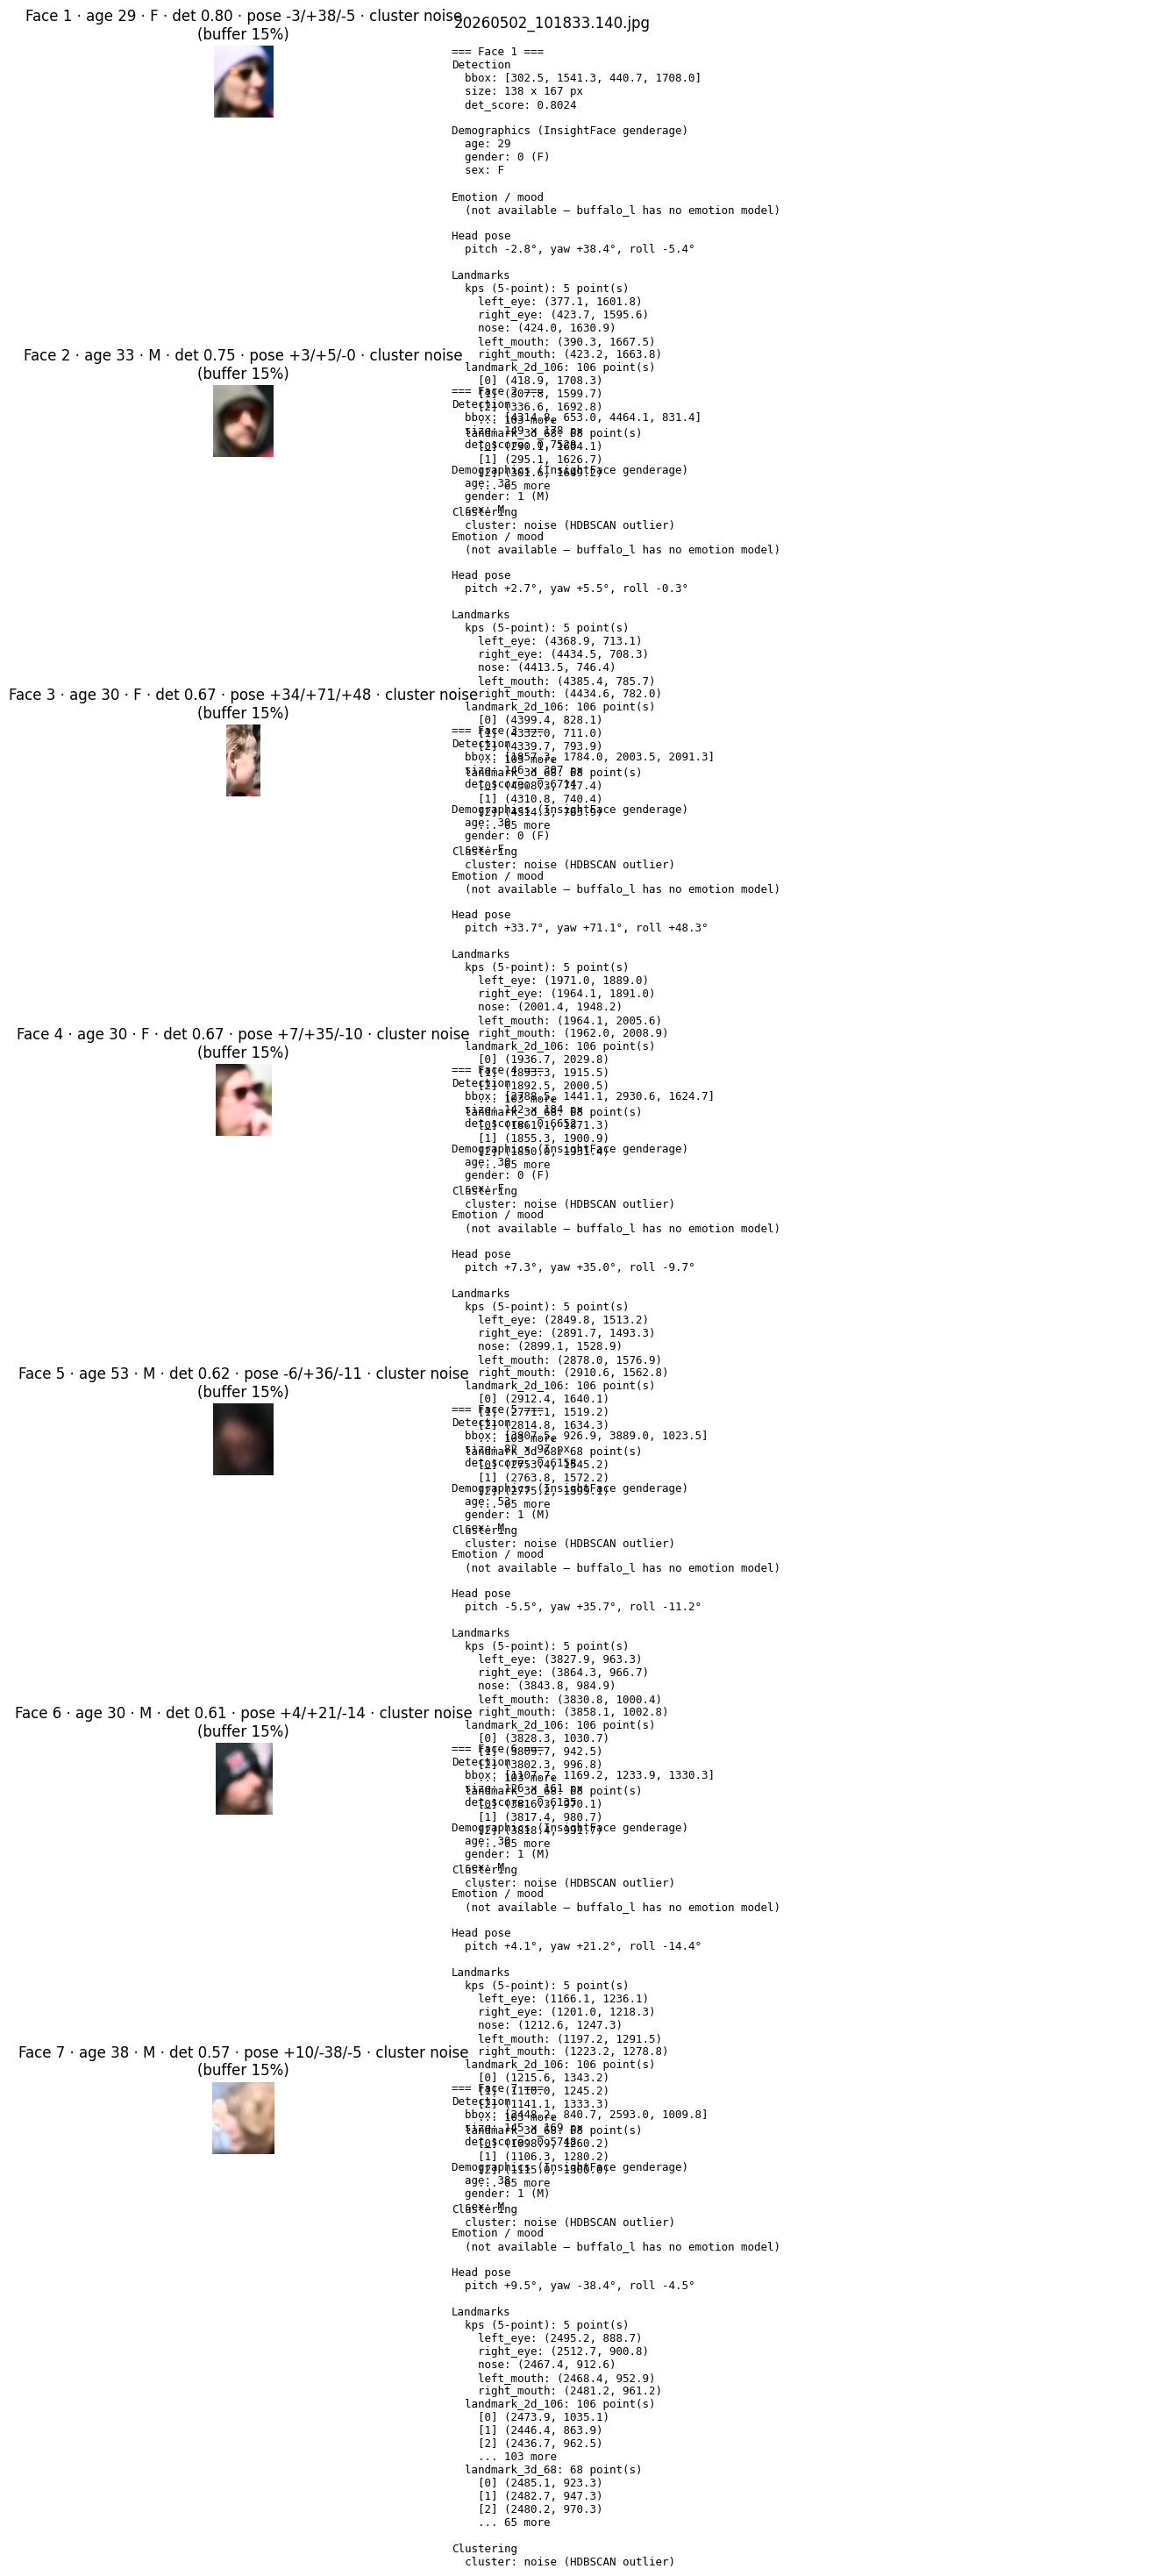

In [4]:
_utils.show_face_metadata_crop_grid(
    image,
    records,
    BUFFER_PCT,
    cluster_labels=cluster_labels,
    title=IMAGE_PATH.name,
    use_buffered=True,
)

## Full text attributes

Same fields as the crop panels, in plain text (useful for copy/paste or headless runs).

In [5]:
_face_info.print_all_face_attributes(
    records,
    cluster_labels=cluster_labels,
    source=source,
)

Source: sidecar
Faces: 7
Note: re-scan with `mf scan IMAGE --tools scrfd,arcface,dlib_detect,dlib_embed --force` if fields are missing (pre-1.1.0 sidecars stored partial data).

=== Face 1 ===
Detection
  bbox: [302.5, 1541.3, 440.7, 1708.0]
  size: 138 x 167 px
  det_score: 0.8024

Demographics (InsightFace genderage)
  age: 29
  gender: 0 (F)
  sex: F

Emotion / mood
  (not available — buffalo_l has no emotion model)

Head pose
  pitch -2.8°, yaw +38.4°, roll -5.4°

Landmarks
  kps (5-point): 5 point(s)
    left_eye: (377.1, 1601.8)
    right_eye: (423.7, 1595.6)
    nose: (424.0, 1630.9)
    left_mouth: (390.3, 1667.5)
    right_mouth: (423.2, 1663.8)
  landmark_2d_106: 106 point(s)
    [0] (418.9, 1708.3)
    [1] (307.8, 1599.7)
    [2] (336.6, 1692.8)
    ... 103 more
  landmark_3d_68: 68 point(s)
    [0] (290.1, 1604.1)
    [1] (295.1, 1626.7)
    [2] (301.6, 1649.2)
    ... 65 more

Clustering
  cluster: noise (HDBSCAN outlier)

=== Face 2 ===
Detection
  bbox: [4314.8, 653.0, 4